# Telecom Churn - Exploratory Data Analysis
looking at the cleaned data from snowflake to figure out patterns in who churns and why

In [17]:
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

load_dotenv('../.env')

conn = snowflake.connector.connect(
    user=os.getenv('SNOWFLAKE_USER'),
    password=os.getenv('SNOWFLAKE_PASSWORD'),
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
    database=os.getenv('SNOWFLAKE_DATABASE'),
    schema='CLEAN'
)

ibm_maven = pd.read_sql('SELECT * FROM IBM_MAVEN', conn)
kaggle = pd.read_sql('SELECT * FROM KAGGLE_TELECOMS', conn)

print(f'IBM+Maven: {ibm_maven.shape}')
print(f'Kaggle: {kaggle.shape}')

/var/folders/9v/m7xlhp3j2cz1nmdxztqqdw200000gn/T/ipykernel_6018/4126713845.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ibm_maven = pd.read_sql('SELECT * FROM IBM_MAVEN', conn)
/var/folders/9v/m7xlhp3j2cz1nmdxztqqdw200000gn/T/ipykernel_6018/4126713845.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  kaggle = pd.read_sql('SELECT * FROM KAGGLE_TELECOMS', conn)


IBM+Maven: (6589, 34)
Kaggle: (3333, 22)


In [18]:
# what columns do we have to work with?
print(ibm_maven.columns.tolist())

['CUSTOMERID', 'GENDER', 'AGE', 'MARRIED', 'DEPENDENTS', 'CITY', 'ZIP_CODE', 'SENIORCITIZEN', 'TENURE', 'PHONESERVICE', 'MULTIPLELINES', 'INTERNETSERVICE', 'INTERNET_TYPE', 'ONLINESECURITY', 'ONLINEBACKUP', 'DEVICEPROTECTION', 'TECHSUPPORT', 'STREAMINGTV', 'STREAMINGMOVIES', 'STREAMING_MUSIC', 'UNLIMITED_DATA', 'CONTRACT', 'PAPERLESSBILLING', 'PAYMENTMETHOD', 'MONTHLYCHARGES', 'TOTALCHARGES', 'TOTAL_REVENUE', 'TOTAL_REFUNDS', 'NUMBER_OF_REFERRALS', 'OFFER', 'AVG_MONTHLY_GB_DOWNLOAD', 'CHURN', 'CHURN_CATEGORY', 'CHURN_REASON']


In [19]:
# quick sanity check - whats the overall churn situation
print(ibm_maven['CHURN'].value_counts())
print(f"\nchurn rate: {(ibm_maven['CHURN']=='Yes').mean()*100:.1f}%")

print('---')

print(kaggle['CHURN_FLAG'].value_counts())
print(f"\nchurn rate: {(kaggle['CHURN_FLAG']=='Yes').mean()*100:.1f}%")

CHURN
No     4720
Yes    1869
Name: count, dtype: int64

churn rate: 28.4%
---
CHURN_FLAG
No     2850
Yes     483
Name: count, dtype: int64

churn rate: 14.5%


In [20]:
# ibm+maven is 28% churn, kaggle is 14%... thats pretty different
# might be because theyre from different companies/time periods
# keeping them separate for now and analyzing each on its own

In [21]:
# check for missing data
nulls = ibm_maven.isnull().sum()
print(nulls[nulls > 0])

INTERNET_TYPE              1344
STREAMING_MUSIC            1344
UNLIMITED_DATA             1344
TOTALCHARGES                 11
OFFER                      3598
AVG_MONTHLY_GB_DOWNLOAD    1344
CHURN_CATEGORY             4720
CHURN_REASON               4720
dtype: int64


In [22]:
# so INTERNET_TYPE, STREAMING_MUSIC, UNLIMITED_DATA, AVG_MONTHLY_GB_DOWNLOAD
# are null for ~1344 rows — these are probably customers with no internet
# CHURN_CATEGORY and CHURN_REASON are null for 4720 - makes sense, 
# those are the people who STAYED so theres no reason
# TOTALCHARGES has 11 nulls - ill deal with those later
# OFFER has 3598 nulls - customers who werent given any offer

print(kaggle.isnull().sum().sum())  # kaggle has zero nulls, nice

0


In [23]:
os.makedirs('figures', exist_ok=True)

---
## 1. Churn by Contract Type
month to month should be way higher, people with annual contracts are locked in

In [24]:
# lets check the contract types first
print(ibm_maven['CONTRACT'].value_counts())

CONTRACT
Month-to-month    3445
Two year          1689
One year          1455
Name: count, dtype: int64


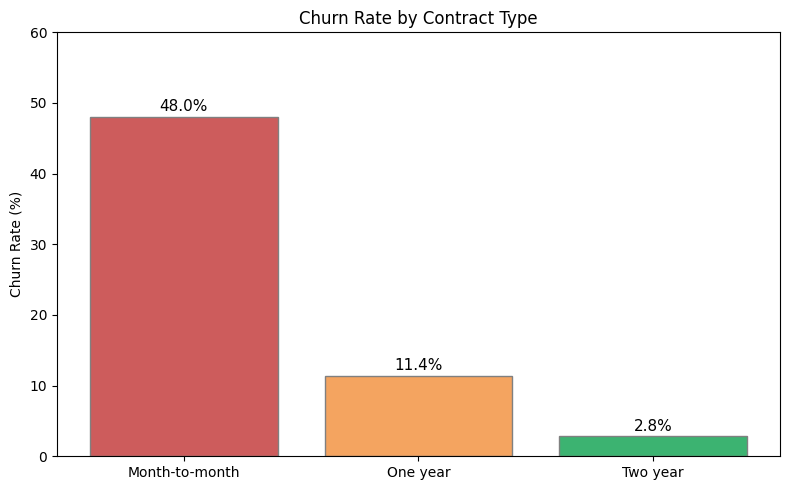

In [25]:
contract_churn = ibm_maven.groupby('CONTRACT')['CHURN'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate (%)']
contract_churn = contract_churn.sort_values('Churn Rate (%)', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(contract_churn['Contract'], contract_churn['Churn Rate (%)'],
              color=['indianred', 'sandybrown', 'mediumseagreen'], edgecolor='gray')

# add percentage labels on top
for bar, val in zip(bars, contract_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', fontsize=11)

ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Contract Type')
ax.set_ylim(0, 60)
plt.tight_layout()
plt.savefig('figures/01_churn_by_contract.png', dpi=150)
plt.show()

In [26]:
# yep 48% for month to month.. thats almost half of them leaving
# two year is only 2.8% which makes sense - theyre committed
# biggest takeaway: get people off month to month contracts

## 2. Churn by Tenure
wanna see if new customers churn more than long-time ones

In [27]:
# breaking tenure into buckets
ibm_maven['TENURE_COHORT'] = pd.cut(ibm_maven['TENURE'], 
    bins=[0, 6, 12, 24, 100],
    labels=['0-6 mo', '6-12 mo', '12-24 mo', '24+ mo'])

# just checking the distribution real quick
print(ibm_maven['TENURE_COHORT'].value_counts().sort_index())

TENURE_COHORT
0-6 mo      1016
6-12 mo      705
12-24 mo    1024
24+ mo      3833
Name: count, dtype: int64


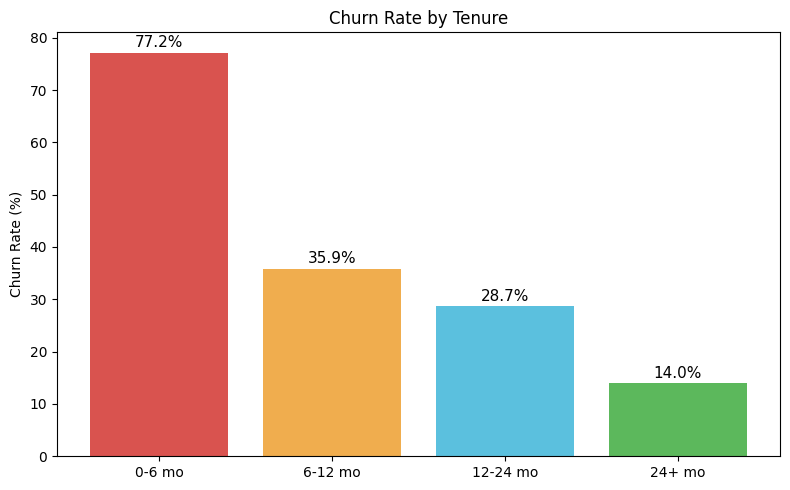

In [28]:
tenure_churn = ibm_maven.groupby('TENURE_COHORT', observed=True)['CHURN'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
tenure_churn.columns = ['Cohort', 'Churn Rate (%)']

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c']
bars = ax.bar(tenure_churn['Cohort'], tenure_churn['Churn Rate (%)'],
              color=colors)

for bar, val in zip(bars, tenure_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=11)

ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Tenure')
plt.tight_layout()
plt.savefig('figures/02_churn_by_tenure.png', dpi=150)
plt.show()

In [29]:
# 77% churn in first 6 months!!! thats insane
# basically if you survive the first 6 months you're way less likely to leave
# this is the danger zone - company needs to focus retention efforts here

## 3. Why did customers actually leave?
this is the best part of the maven dataset - it has actual churn reasons

In [30]:
# what are the churn categories?
print(ibm_maven[ibm_maven['CHURN']=='Yes']['CHURN_CATEGORY'].value_counts())

CHURN_CATEGORY
Competitor         841
Dissatisfaction    321
Attitude           314
Price              211
Other              182
Name: count, dtype: int64


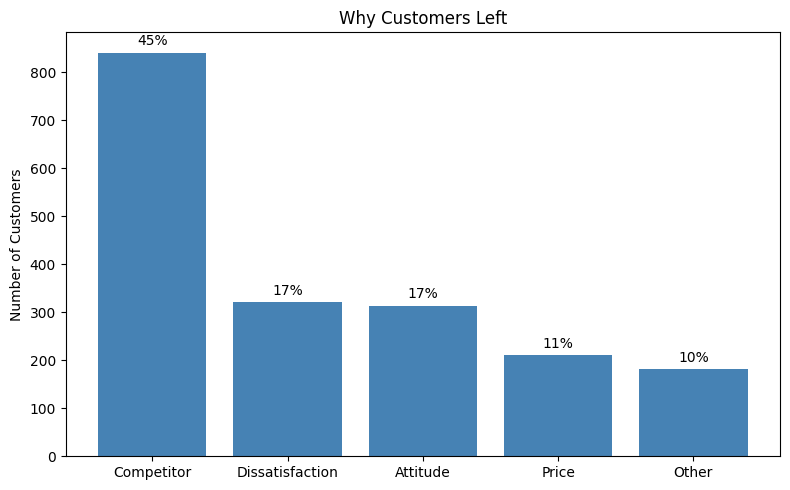

In [31]:
reasons = ibm_maven[ibm_maven['CHURN'] == 'Yes']['CHURN_CATEGORY'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(reasons.index, reasons.values, color='steelblue')

# adding percentages
for i, (val, name) in enumerate(zip(reasons.values, reasons.index)):
    pct = val / reasons.sum() * 100
    ax.text(i, val + 15, f'{pct:.0f}%', ha='center', fontsize=10)

ax.set_ylabel('Number of Customers')
ax.set_title('Why Customers Left')
plt.tight_layout()
plt.savefig('figures/03_churn_reasons.png', dpi=150)
plt.show()

In [32]:
# 45% left for a competitor - thats the #1 reason by far
# so its not really about price (only 11%) - its about competitors offering better deals
# dissatisfaction and attitude (bad service) together are 34% which is also huge

# lets also look at the specific reasons within each category
print(ibm_maven[ibm_maven['CHURN']=='Yes']['CHURN_REASON'].value_counts().head(10))

CHURN_REASON
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Name: count, dtype: int64


## 4. Customer Service Calls (Kaggle data)
the kaggle dataset has customer service call counts - wondering if theres a threshold where churn spikes

In [33]:
# how many service calls do people make?
print(kaggle['CUSTOMER_SERVICE_CALLS'].value_counts().sort_index())

CUSTOMER_SERVICE_CALLS
0     697
1    1181
2     759
3     429
4     166
5      66
6      22
7       9
8       2
9       2
Name: count, dtype: int64


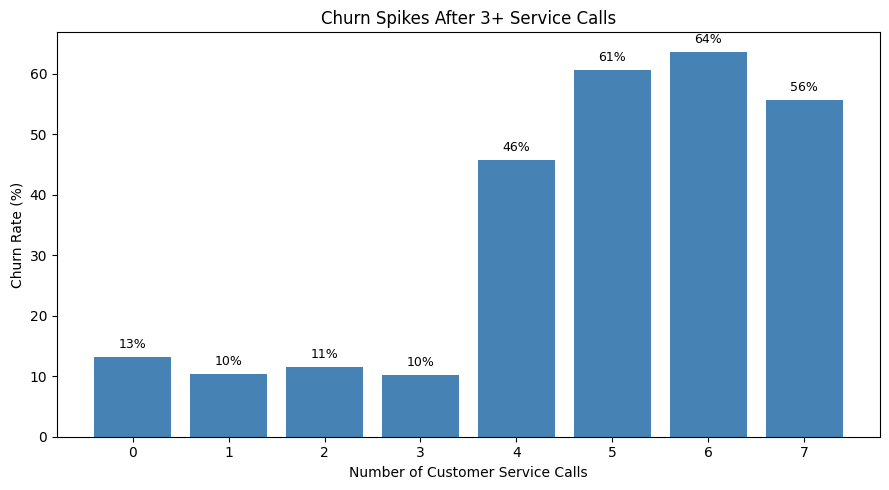

In [34]:
cs_churn = kaggle.groupby('CUSTOMER_SERVICE_CALLS')['CHURN_FLAG'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
cs_churn.columns = ['Calls', 'Churn Rate (%)']

# only showing up to 7 calls, after that sample size gets too small
cs_churn = cs_churn[cs_churn['Calls'] <= 7]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(cs_churn['Calls'], cs_churn['Churn Rate (%)'], color='steelblue')

for _, row in cs_churn.iterrows():
    ax.text(row['Calls'], row['Churn Rate (%)'] + 1.5,
            f"{row['Churn Rate (%)']:.0f}%", ha='center', fontsize=9)

ax.set_xlabel('Number of Customer Service Calls')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Spikes After 3+ Service Calls')
plt.tight_layout()
plt.savefig('figures/04_churn_by_service_calls.png', dpi=150)
plt.show()

In [35]:
# there's a clear cutoff at 4 calls
# 0-3 calls: churn is around 10-13%, pretty normal
# 4 calls: jumps to 46%
# 5-6 calls: 60%+
# takeaway: if someone calls support a 4th time, flag them for retention

## 5. Correlation Heatmap
checking which numeric features are most correlated with churn

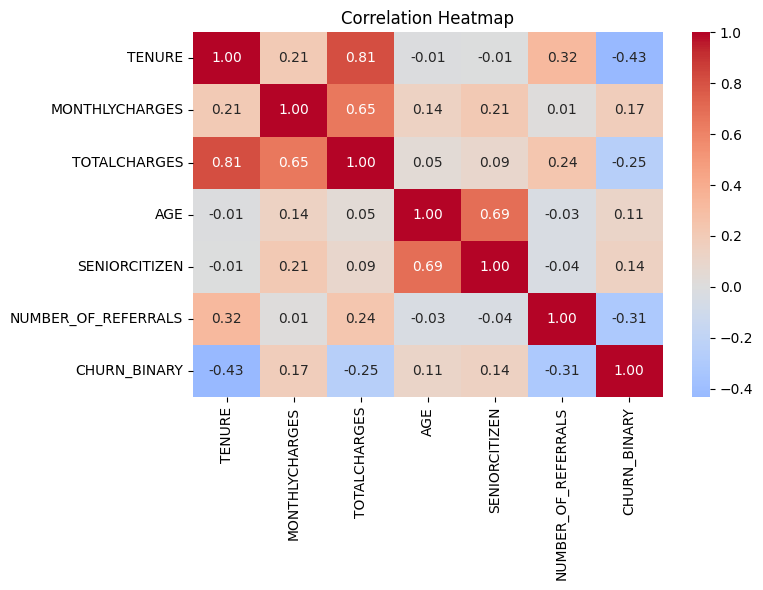

In [36]:
ibm_maven['CHURN_BINARY'] = (ibm_maven['CHURN'] == 'Yes').astype(int)

cols_to_check = ['TENURE', 'MONTHLYCHARGES', 'TOTALCHARGES', 'AGE', 
                 'SENIORCITIZEN', 'NUMBER_OF_REFERRALS', 'CHURN_BINARY']
corr = ibm_maven[cols_to_check].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('figures/05_correlation_heatmap.png', dpi=150)
plt.show()

In [37]:
# tenure has the strongest negative correlation with churn (-0.43)
# which matches what we saw in the tenure chart
# number of referrals is also negatively correlated (-0.31) 
# makes sense - happy customers refer people, unhappy ones dont
# monthly charges is slightly positive (0.17) - higher bill = more likely to leave

## 6. Monthly Charges - Churned vs Stayed

In [38]:
# comparing the distribution of monthly charges
print('stayed avg:', ibm_maven[ibm_maven['CHURN']=='No']['MONTHLYCHARGES'].mean().round(2))
print('churned avg:', ibm_maven[ibm_maven['CHURN']=='Yes']['MONTHLYCHARGES'].mean().round(2))

stayed avg: 62.98
churned avg: 74.44


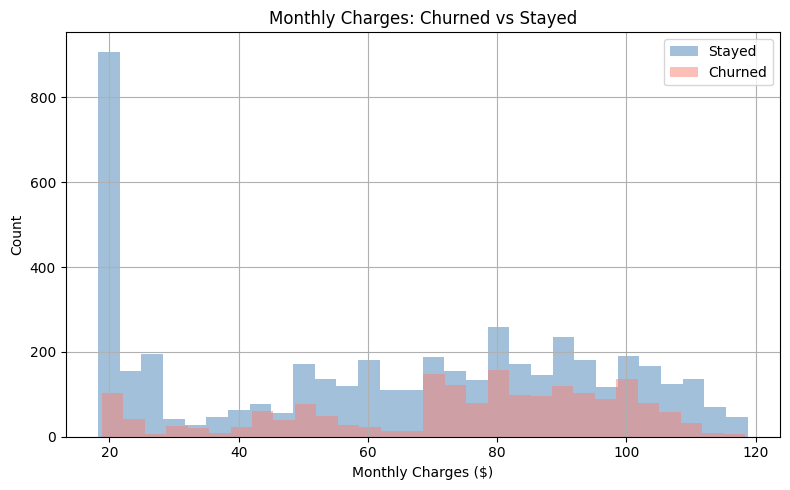

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
ibm_maven[ibm_maven['CHURN']=='No']['MONTHLYCHARGES'].hist(
    bins=30, alpha=0.5, label='Stayed', color='steelblue', ax=ax)
ibm_maven[ibm_maven['CHURN']=='Yes']['MONTHLYCHARGES'].hist(
    bins=30, alpha=0.5, label='Churned', color='salmon', ax=ax)
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Count')
ax.set_title('Monthly Charges: Churned vs Stayed')
ax.legend()
plt.tight_layout()
plt.savefig('figures/06_monthly_charges_dist.png', dpi=150)
plt.show()

In [40]:
# theres a big spike of low-paying customers (~$20) who stayed
# but in the $60-120 range the churned group is almost the same size as stayed
# so higher paying customers are more likely to leave
# probably because they have more options and competitors target them

---
## Key Takeaways from EDA

1. **Contract type matters most** - 48% of month-to-month customers churn vs 2.8% for two-year
2. **First 6 months is the danger zone** - 77% churn rate for new customers
3. **#1 reason for leaving is competitors** (45%) - not price
4. **Customer service calls are a warning sign** - churn jumps from ~11% to 46% after 4+ calls
5. **Tenure is the strongest predictor** of churn (correlation: -0.43)
6. **Higher paying customers churn more** - need to focus retention on high-value accounts